<a href="https://colab.research.google.com/github/jose-esquivel-dev/Analitica_de_Datos/blob/main/Practica_2/Actividad2_DelgadoRam%C3%ADrez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

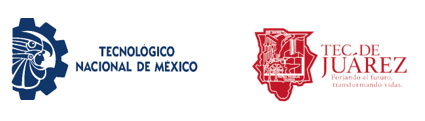

#**INSTITUTO TECNOLOGICO DE CIUDAD JUAREZ**
**Ciencia y analítica de datos**

MODELOS DE APRENDIZAJE


**ACTIVIDAD 2**: *Exploración de datos*

---

*   NOMBRE: María Fernanda Delgado Ramírez
*   NO. CONTROL: 23111480

# Código para acceder a Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importación de librerías necesarias

In [2]:
#libreria manipulacion de datos
import pandas as pd

#libreria para calculos numericos y estadisticos
import numpy as np

#libreria para graficos
import matplotlib.pyplot as plt
import seaborn as sns


# Carga del archivo CSV como DataFrame

In [3]:
cred_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Analisis/credit_risk_dataset.csv')
cred_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


# **Parte 1.** Análisis descriptivo (univariante)

1. Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas cualitativas?

In [4]:
#.info() muestra la informacion del dataframe numero de columnas y del tipo de dato de cada una de las columnas
cred_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


El método `info()` muestra que el conjunto de datos está compuesto por 12 columnas y 32,581 registros. Ocho de estas columnas corresponden a variables numéricas de tipo entero o decimal, entre ellas `person_age, person_income, person_emp_length, loan_amnt, loan_int_rate, loan_status, loan_percent_income` y` cb_person_cred_hist_length`. Las cuatro columnas restantes son variables cualitativas de tipo object, correspondientes a `person_home_ownership, loan_intent, loan_grade` y `cb_person_default_on_file`. Y asimismo, se observa que las columnas `person_emp_length` y `loan_int_rate` contienen valores nulos, dado que su conteo de registros no nulos resulta menor al total de filas del dataframe.

 2. Determina el porcentaje de valores faltantes por columna.

In [5]:
#.isna() revisa si existen valores nulos
cred_df.isna()
#.mean() calcula promedio
cred_df.isna().mean()*100

,0
person_age,0.000000
person_income,0.000000
person_home_ownership,0.000000
person_emp_length,2.747000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_int_rate,9.563856
loan_status,0.000000
loan_percent_income,0.000000


El porcentaje de valores faltantes por columna evidencia que la mayoría de las variables está completa. Únicamente dos columnas presentan valores nulos: `person_emp_length`, con 2.74% de datos faltantes, y `loan_int_rate`, con 9.56% de datos faltantes, siendo esta última la variable con mayor proporción de valores ausentes del conjunto de datos. El resto de las columnas no reporta ningún valor faltante.

# *Análisis de variables numéricas*

*   Elemento de la lista
*   Elemento de la lista



3. Obtén las siguientes estadísticas descriptivas para todas las variables numéricas:
*   Tendencia central (media, mediana)
*   Dispersión o variabilidad (min, max, desviación estándar, cuartiles)
*   Forma (asimetría y curtosis)
*   Clasifica las variables `person_age` y `loan_in_rate` según los valores observados de asimetría y curtosis

**NOTA**. Recuerda que muchas de estas estadísticas, puedes obtenerlas utilizando la función `describe()` y que la mediana está representada en el 2do cuartil (50%)

**Estadísticas descriptivas**

In [6]:
cred_df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
cred_df.skew(numeric_only=True)

,0
person_age,2.581393
person_income,32.865349
person_emp_length,2.614455
loan_amnt,1.192477
loan_int_rate,0.208550
loan_status,1.364888
loan_percent_income,1.064669
cb_person_cred_hist_length,1.661790


In [8]:
cred_df.kurt(numeric_only=True)

,0
person_age,18.560825
person_income,2693.272776
person_emp_length,43.722338
loan_amnt,1.423565
loan_int_rate,-0.671609
loan_status,-0.137088
loan_percent_income,1.223687
cb_person_cred_hist_length,3.716194


In [9]:
cred_df.min()

,0
person_age,20
person_income,4000
person_home_ownership,MORTGAGE
person_emp_length,0.0
loan_intent,DEBTCONSOLIDATION
loan_grade,A
loan_amnt,500
loan_int_rate,5.42
loan_status,0
loan_percent_income,0.0


In [10]:
cred_df.max()


,0
person_age,144
person_income,6000000
person_home_ownership,RENT
person_emp_length,123.0
loan_intent,VENTURE
loan_grade,G
loan_amnt,35000
loan_int_rate,23.22
loan_status,1
loan_percent_income,0.83


In [11]:
cred_df.std(numeric_only=True)

,0
person_age,6.348078
person_income,61983.119168
person_emp_length,4.142630
loan_amnt,6322.086646
loan_int_rate,3.240459
loan_status,0.413006
loan_percent_income,0.106782
cb_person_cred_hist_length,4.055001


In [12]:
cred_df.quantile([0.25, 0.5, 0.75], numeric_only=True)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
0.25,23.0,38500.0,2.0,5000.0,7.90,0.0,0.09,3.0
0.50,26.0,55000.0,4.0,8000.0,10.99,0.0,0.15,4.0
0.75,30.0,79200.0,7.0,12200.0,13.47,0.0,0.23,8.0


Con estos datos podemos ver cómo se comportan la edad y la tasa de interés del préstamo. La edad tiene una mediana de 26 años, o sea que la mitad de las personas tiene menos de 26 y la otra mitad más. Y si nos fijamos en dónde se concentra la mayoría, casi todos están entre los 23 y los 30 años. Además, no hay mucha variación entre una persona y otra, en promedio la edad se aleja del centro solo unos 6 años, así que la mayoría son gente joven.

El ingreso es diferente porque varía muchísimo más entre las personas. Por ejemplo, el 75% de los solicitantes gana menos de 79,200 dólares, pero hay alguien que gana hasta 6,000,000 de dólares, lo cual es una diferencia enorme comparado con el resto. Eso ya nos avisa que hay valores muy fuera de lo normal en esta variable.

Ahora, si vemos qué tan "extraña" o estirada es la forma en que se distribuyen los datos, la edad sale con un número muy alto, 18.56, lo que quiere decir que hay bastantes casos raros o extremos jalando la distribución. Y esto tiene mucho sentido, porque el valor máximo registrado es de 144 años, que obviamente es un error, nadie tiene esa edad. La mayoría de la gente es joven y nada más unos cuantos casos exagerados son los que hacen que se vea así.

En cambio la tasa de interés sale con un número de -0.67, cercano a cero, lo que significa que no tiene esos casos tan extremos como la edad. Su mediana es de 10.99% y la mayoría de los valores se mueve entre 7.90% y 13.47%, así que se ve una distribución bastante más pareja y normal.

4. Utiliza histogramas para determinar la distribución de los valores representados en cada variable.
*   ¿Se corresponde con lo obtenido en el cálculo de asimetría? Como verás, los datos reales son más complejos que la teoría. Por esta razón, recuerda siempre acompañar el análisis de la asimetría con algún gráfico como un histograma.

**NOTA**. Para esto también puedes ocupar los gráficos `kde` ([kernel density estimation](https://www.cienciadedatos.net/documentos/pystats02-kernel-density-estimation-kde-python.html)) que crean una curva continua y suave expandiendo la idea del histograma.

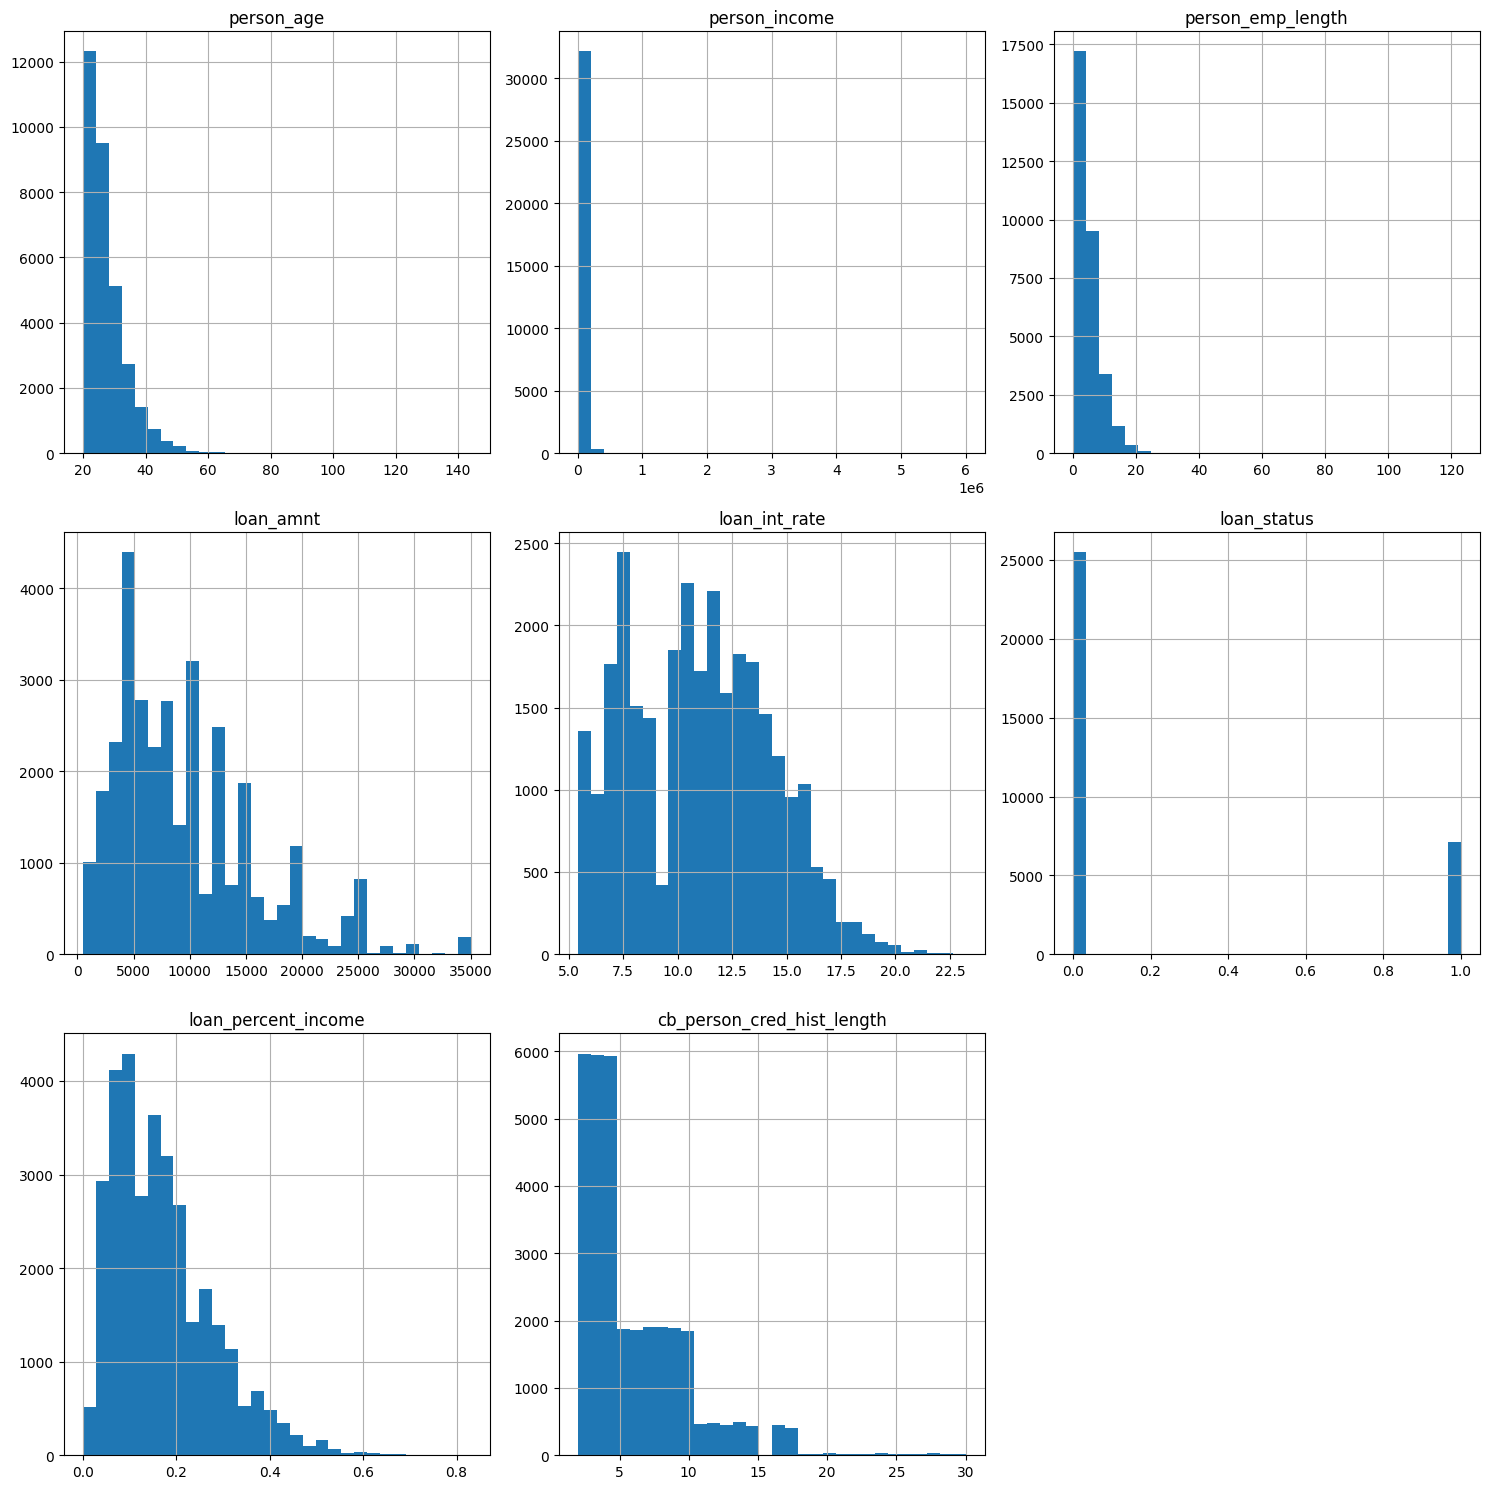

In [13]:
cred_df.hist(figsize=(15,15), bins=30)
plt.tight_layout()
plt.show()

Los histogramas confirman lo que ya habíamos visto con la curtosis, y en general sí se corresponde con lo obtenido en el cálculo de asimetría: la edad, el ingreso, los años trabajando y el porcentaje del ingreso destinado al préstamo tienen la mayoría de sus valores concentrados en números bajos, con solo unos cuantos casos extremos que hacen que la gráfica se estire hacia la derecha, tal como lo marcaba su asimetría positiva.

Donde sí se nota una diferencia es en el monto del préstamo. También salió con asimetría positiva, pero su histograma no es una sola cola estirada, sino que tiene varios picos, marcando los montos que la gente pide con más frecuencia.

La tasa de interés, en cambio, se ve más pareja y parecida a una campana, aunque con algunos picos irregulares, lo cual coincide con que su curtosis haya salido negativa. Por último, loan_status, que indica si el préstamo actual cayó en incumplimiento, y `cb_person_default_on_file`, que indica si la persona ya había incumplido algún crédito antes, son variables que solo pueden tomar dos valores, por eso sus gráficas muestran nada más dos barras, una mucho más alta que la otra porque en ambos casos la mayoría de los casos corresponde a que no hubo incumplimiento.

5. Emplea boxplots para mostrar la distribución de los datos a través de sus cuartiles.

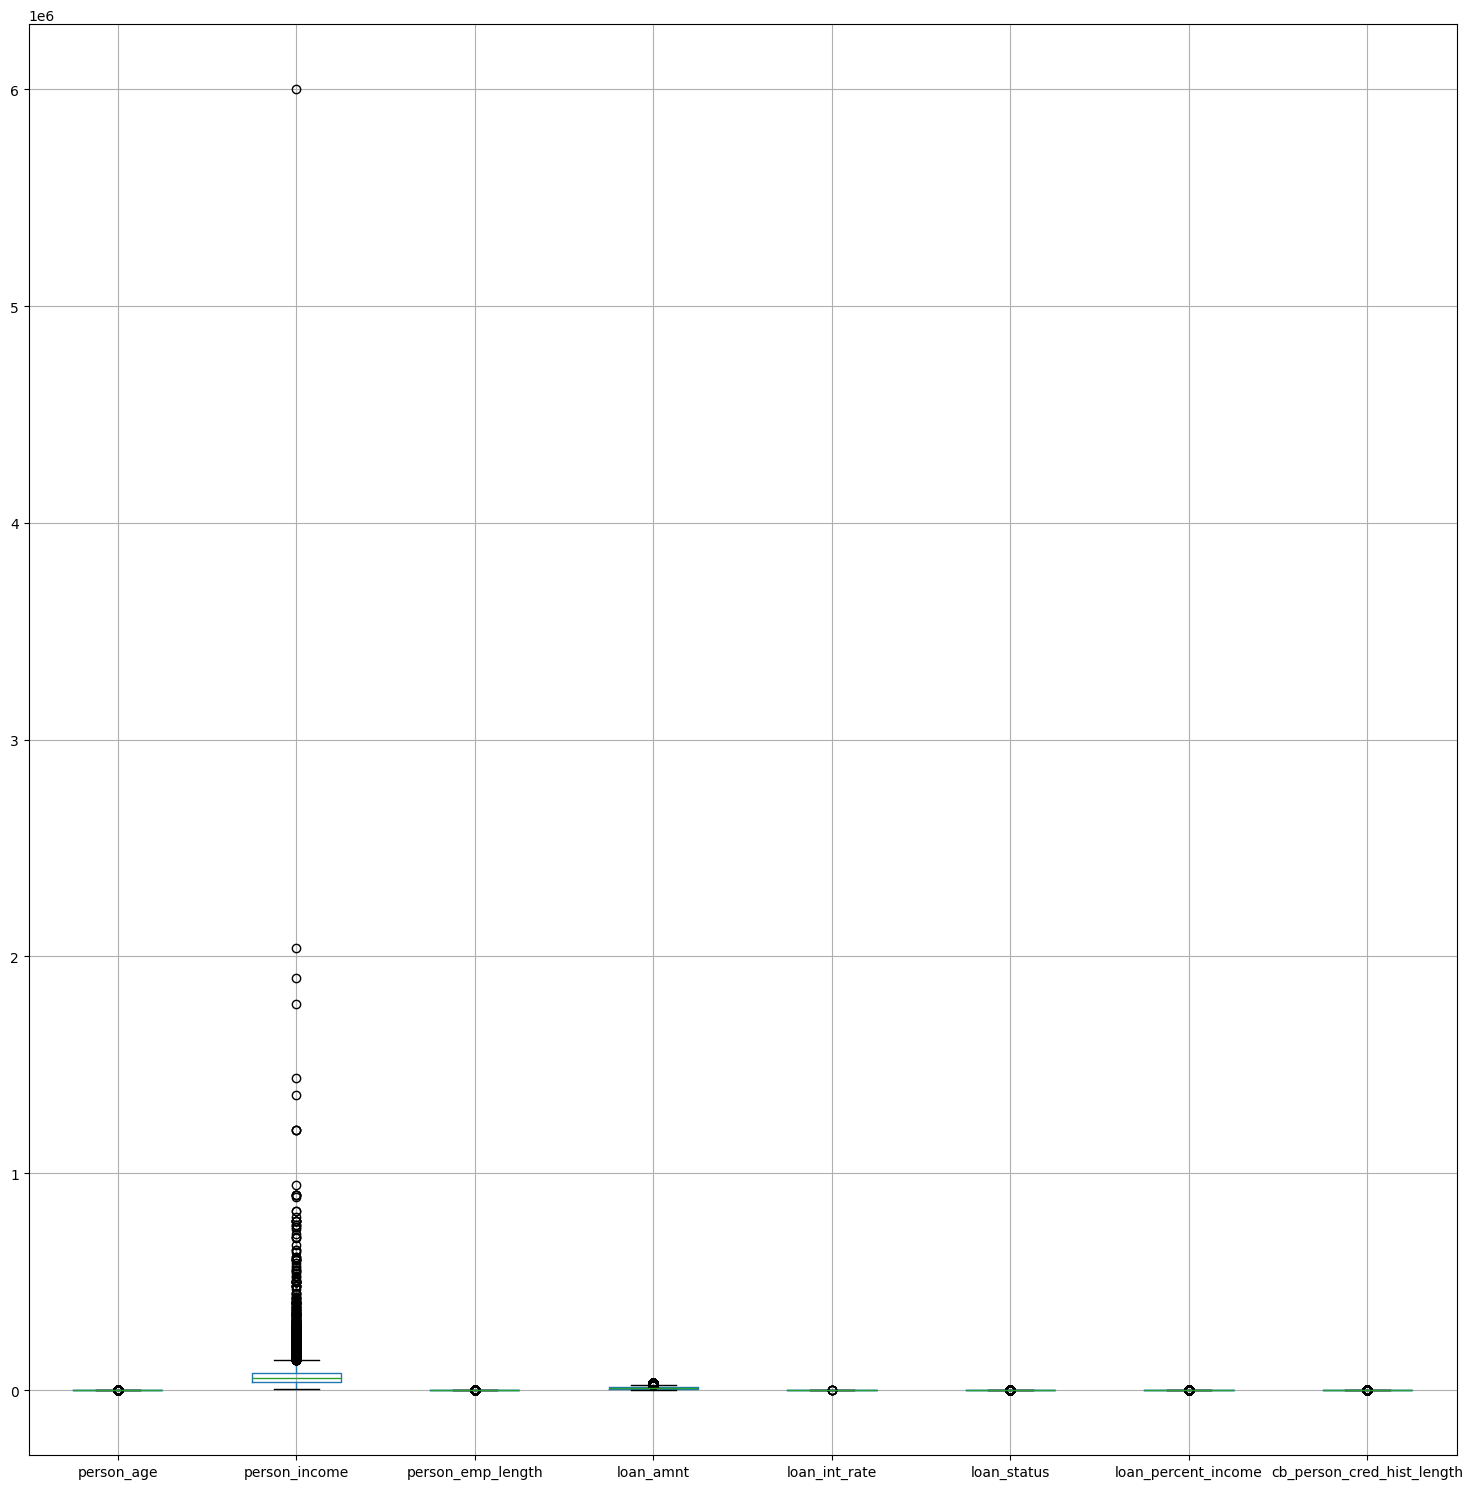

In [14]:
cred_df.boxplot(figsize=(15,15))
plt.tight_layout()
plt.show()

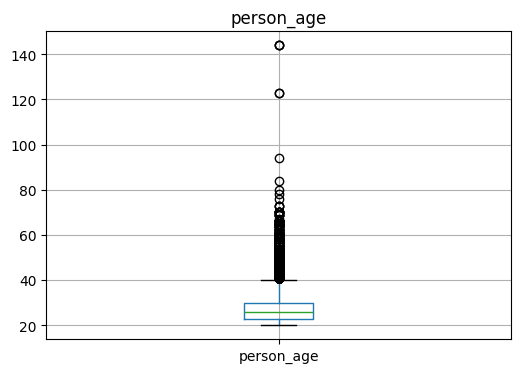

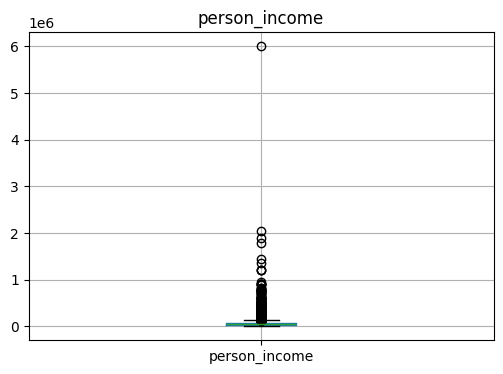

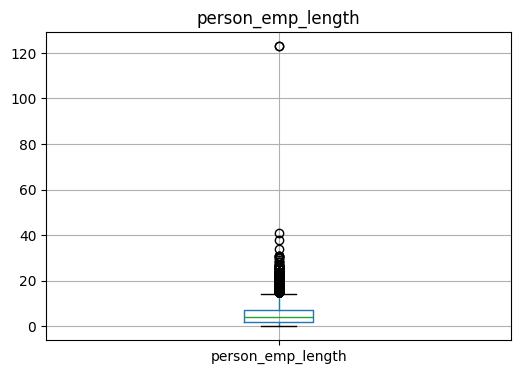

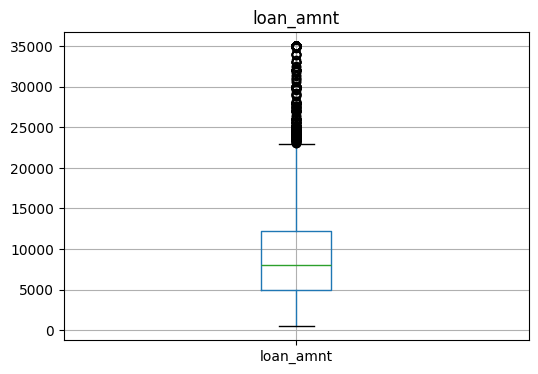

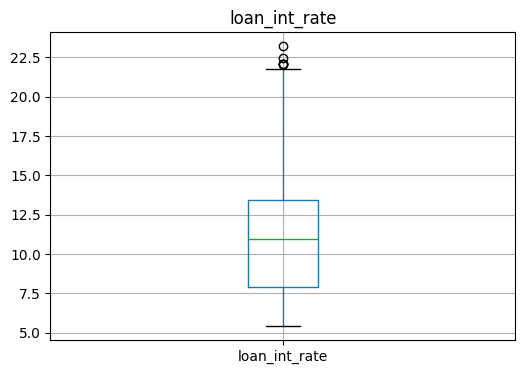

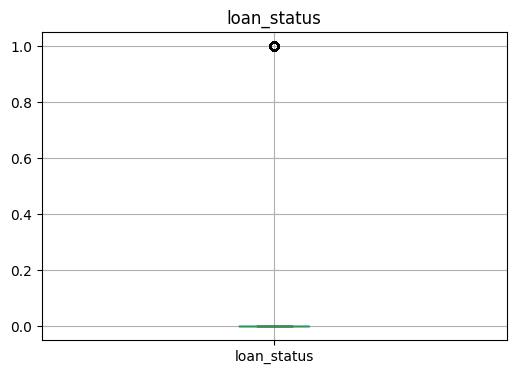

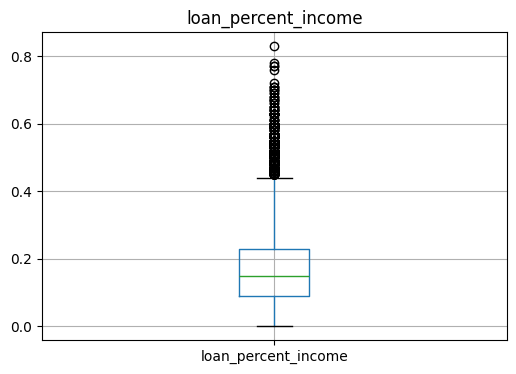

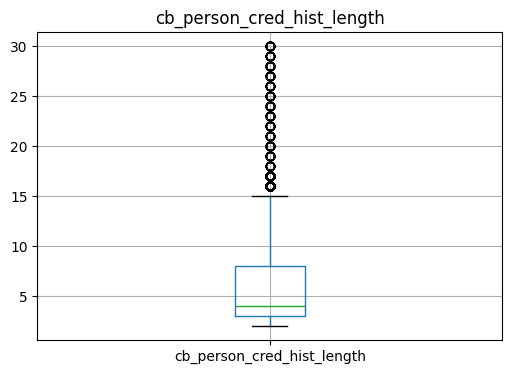

In [15]:
for col in cred_df.select_dtypes(include='number').columns:
    plt.figure(figsize=(6, 4))
    cred_df.boxplot(column=col)
    plt.title(col)
    plt.show()

Los boxplots muestran que todas las variables numéricas tienen valores atípicos, pero no todas en la misma medida. La que más destaca es el ingreso, porque mientras la mayoría de las personas gana menos de 80,000 dólares, hay casos que llegan hasta los 6,000,000, y eso hace que en el boxplot general esta variable domine toda la gráfica y no deje ver bien a las demás. Algo parecido pasa con la edad, donde aparecen valores de 144 y 123 años, que claramente no son reales y seguro se deben a errores al capturar los datos.

La tasa de interés también tiene algunos valores atípicos, pero más moderados, arriba del 21%, y el monto del préstamo tiene unos cuantos casos altos cerca de su máximo de 35,000 dólares. En general, todo esto deja ver que antes de usar estos datos para entrenar un modelo, hay que limpiar o tratar estos valores atípicos.

*   Como podrás observar hay valores atípicos en todas las variables. Ejecuta el siguiente código para identificar los valores atípicos en la variable `person_age`

In [16]:
#COMENTE CADA LINEA DE CODIGO EXPLICANDO SU USO

percentile_25 = cred_df["person_age"].quantile(0.25)
percentile_75 = cred_df["person_age"].quantile(0.75)

iqr = percentile_75 - percentile_25

upper_limit = percentile_75 + 1.5 * iqr
lower_limit = percentile_25 - 1.5 * iqr

IQR_outliers = cred_df[(cred_df["person_age"] < lower_limit) | (cred_df["person_age"] > upper_limit)]
IQR_outliers

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
29121,50,900000,MORTGAGE,11.0,DEBTCONSOLIDATION,B,30000,12.69,0,0.03,N,15
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


La tabla de valores atípicos calculada mediante el criterio del rango intercuartílico confirma la presencia de registros con edades poco plausibles dentro del dataset. Los casos más extremos corresponden a solicitantes de 144 y 123 años, cifras que exceden por mucho la esperanza de vida y que deben considerarse errores de captura más que valores reales. También se identifican registros con edades cercanas a 50 años asociados a ingresos elevados, lo que resulta coherente dentro del contexto del negocio, ya que un mayor ingreso suele asociarse con una edad más avanzada. En general, estos resultados sugieren que la variable person_age requiere un tratamiento de limpieza antes de emplearse en un modelo predictivo, ya sea mediante la eliminación de los registros con valores imposibles o mediante su acotación a un rango razonable.

# *Análisis de variables de texto*

 6. Obtén las siguientes estadísticas descriptivas para todas las variables de texto:
*   Tendencia central (moda)
*   Cardinalidad (cantidad de valores únicos)
*   Recuentos únicos (número de ocurrencias para cada valor único)

**NOTA**. Un resumen de estas estadísticas, puedes obtenerlas indicando en la función `describe()` que se incluirán sólo las variables de tipo object: `describe(include = 'object')`. Para los recuentos utiliza la función `df['columna'].value_counts()`

In [17]:
#IDENTIFIQUE CUALES SON LAS VARIABLES DE TEXTO

# Selecciona únicamente las columnas de tipo object, es decir, las variables de texto
text_cols = cred_df.select_dtypes(include='object')

# Recorre cada una de esas columnas de texto una por una
for col in text_cols:
    # Imprime el nombre de la columna que se está analizando
    print(f"--- {col} ---")

    # Muestra el valor que más se repite en esa columna (la moda)
    print("Moda:", cred_df[col].mode()[0])

    # Muestra cuántos valores distintos existen en esa columna
    print("Cardinalidad (valores únicos):", cred_df[col].nunique())

    # Indica que a continuación se mostrará cuántas veces aparece cada valor
    print("Recuento por valor:")

    # Cuenta y muestra cuántas veces se repite cada valor único dentro de la columna
    print(cred_df[col].value_counts())

    # Deja un espacio en blanco para separar visualmente cada variable
    print()

--- person_home_ownership ---
Moda: RENT
Cardinalidad (valores únicos): 4
Recuento por valor:
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

--- loan_intent ---
Moda: EDUCATION
Cardinalidad (valores únicos): 6
Recuento por valor:
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

--- loan_grade ---
Moda: A
Cardinalidad (valores únicos): 7
Recuento por valor:
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

--- cb_person_default_on_file ---
Moda: N
Cardinalidad (valores únicos): 2
Recuento por valor:
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64



Las estadísticas de las variables de texto muestran que la mayoría de las categorías se concentran en pocos valores. En el tipo de posesión de vivienda, la más común es RENT con 50.48% de los casos, seguida de MORTGAGE con 41.27%, mientras que OWN y OTHER son mucho menos frecuentes, con apenas 7.93% y 0.33%.

En cuanto al motivo del préstamo, el más común es EDUCATION con 19.81%, pero en realidad las seis categorías están bastante parejas entre sí, moviéndose entre 11.07% y 19.81%, sin que ninguna destaque demasiado sobre las demás.

La calificación crediticia se concentra sobre todo en A y B, con 33.08% y 32.08% respectivamente, mientras que las categorías E, F y G, que representan mayor riesgo, juntas no llegan ni al 4% del total. Por último, el 82.37% de los solicitantes no tiene incumplimientos previos registrados, contra un 17.63% que sí los tiene.

7. Utiliza gráficos de barras por variable para representar la frecuencia de cada categoría.

**NOTA**. seaborn posee un gráfico de recuento, para variables de tipo object, que calcula la frecuencia de cada categoría sin necesidad de utilizar la función `value_counts()`. Para generarlo debes indicar la columna: `sns.countplot(x='columna', data=df) `

<Axes: xlabel='person_home_ownership', ylabel='count'>

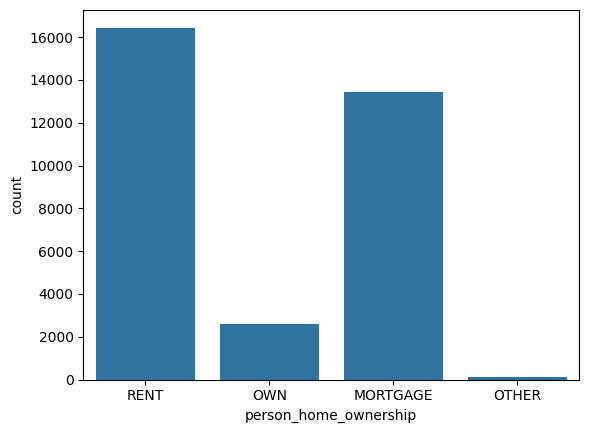

In [18]:
sns.countplot(x='person_home_ownership', data=cred_df)

<Axes: xlabel='loan_intent', ylabel='count'>

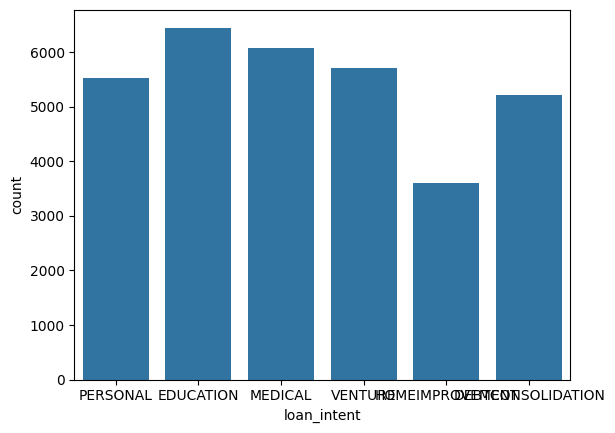

In [19]:
sns.countplot(x='loan_intent', data=cred_df)

<Axes: xlabel='loan_grade', ylabel='count'>

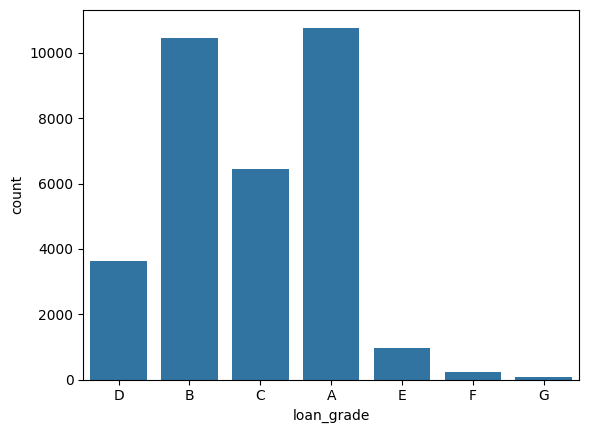

In [20]:
sns.countplot(x='loan_grade', data=cred_df)

<Axes: xlabel='cb_person_default_on_file', ylabel='count'>

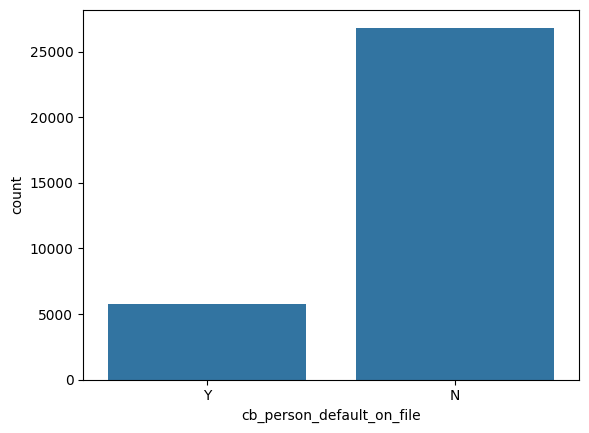

In [21]:
sns.countplot(x='cb_person_default_on_file', data=cred_df)

Las gráficas de barras confirman lo que ya se había visto en las estadísticas de las variables de texto. En el tipo de posesión de vivienda, RENT y MORTGAGE son claramente las barras más altas, juntando más del 90% de los solicitantes, mientras que OWN y OTHER casi no se notan en la gráfica. En el motivo del préstamo, las seis barras se ven bastante parecidas en altura, sin que ninguna sobresalga mucho sobre las demás, lo que confirma que la gente pide préstamos por razones bastante variadas y sin un motivo que domine claramente.

En la calificación crediticia, se nota cómo las barras van bajando entre más avanza la letra, con A y B muy por arriba de C, D, E, F y G, lo que indica que la mayoría de los solicitantes tiene un buen perfil crediticio. Y por último, la gráfica de historial de incumplimiento previo muestra una barra mucho más alta para quienes no han incumplido antes, confirmando que la mayoría de los solicitantes no tiene ese antecedente.

# **Parte 2.** Análisis de correlación (bivariante y multivariante)

La variable `loan_status` será la variable de salida (o a predecir en un modelo de ML). Analiza su relación con el resto de las variables a través de los siguientes gráficos:

8. Un box plot para visualizar la distribución de `loan_percent_income` según el `loan_status`. Interpreta el resultado.

<Axes: title={'center': 'loan_percent_income'}, xlabel='loan_status'>

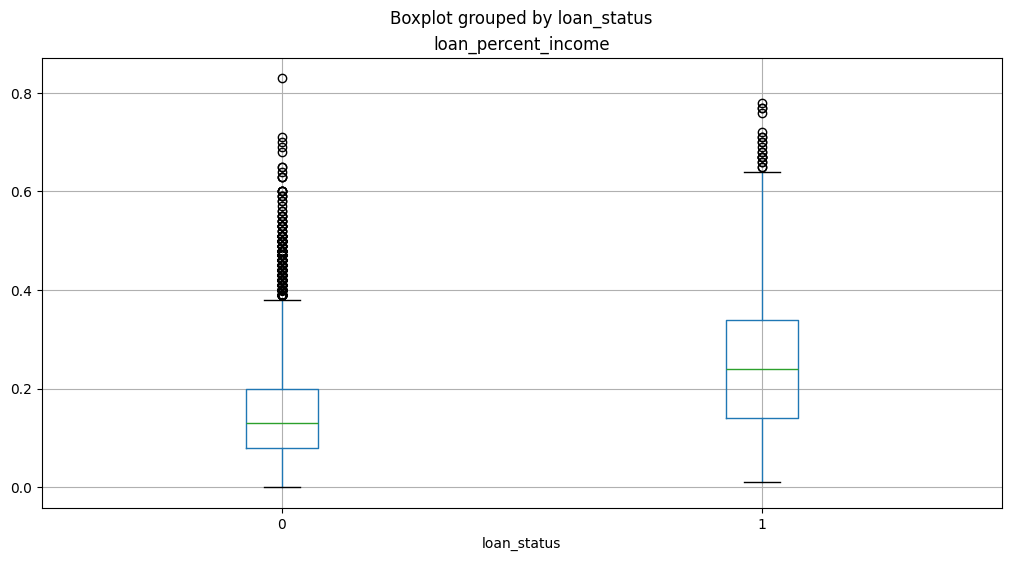

In [22]:
cred_df.boxplot(column='loan_percent_income', by='loan_status', figsize=(12, 6))

El boxplot que compara `loan_percent_income`, el porcentaje del ingreso destinado al préstamo, según los valores de `loan_status`, que indica si hubo o no incumplimiento, muestra una diferencia bastante clara entre los dos grupos. Cuando `loan_status` es 0, es decir, no hubo incumplimiento, `loan_percent_income` tiene en promedio un valor cercano a 0.13, y la mayoría se mueve entre 0.08 y 0.20. En cambio, cuando `loan_status` es 1, es decir, sí hubo incumplimiento, `loan_percent_income` sube bastante más, con un promedio cercano a 0.24, moviéndose la mayoría entre 0.14 y 0.34.

Esto tiene sentido porque entre más ingreso comprometa una persona para pagar su préstamo, menos margen le queda para cubrirlo sin problemas, así que es lógico que quienes destinan una parte más grande de su ingreso, según `loan_percent_income`, sean también quienes más caen en incumplimiento según `loan_status`.

 9. En los gráficos de barras que obtuviste en el ejercicio 7, separa el conteo según el `load_status`, utilizando el parámetro `hue`.

<Axes: xlabel='person_home_ownership', ylabel='count'>

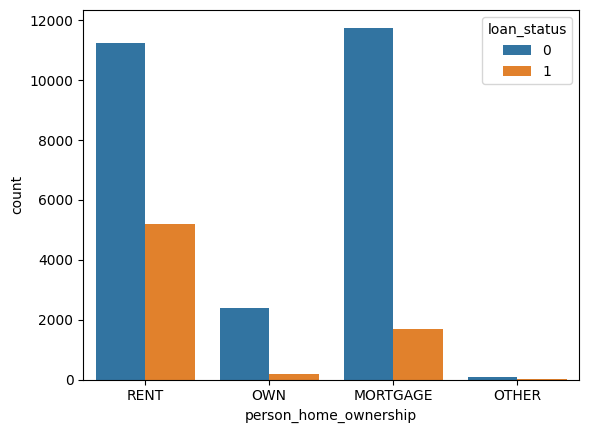

In [23]:
sns.countplot(x='person_home_ownership', data=cred_df, hue='loan_status')

La gráfica de barras separada por `loan_status` muestra qué tanto varía el incumplimiento según el tipo de posesión de vivienda, en `person_home_ownership`. En la categoría RENT, la proporción de solicitantes con incumplimiento es notablemente más alta que en las demás, representando cerca de una tercera parte del total de esa categoría. En MORTGAGE, esa proporción es bastante menor, y en OWN el incumplimiento casi no se nota.

Esto sugiere que el tipo de posesión de vivienda sí está relacionado con el riesgo de incumplimiento, y que las personas que rentan, según `person_home_ownership`, representan un segmento con mayor riesgo dentro del conjunto de datos.

10. Un mapa de calor con los valores de correlación de todas las variables del dataframe.
*   ¿Qué variable tiene mayor correlación con `loan_status`?

<Axes: >

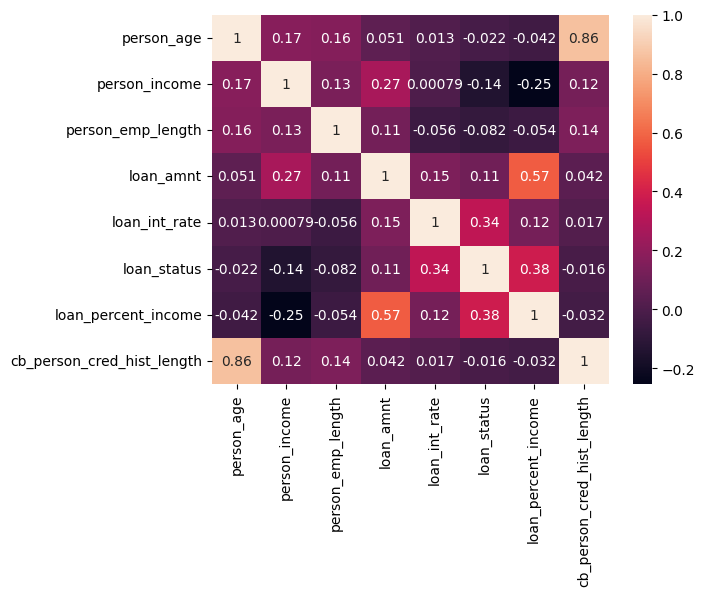

In [24]:
#CODIGO PARA MAPA DE CALOR
sns.heatmap(cred_df.corr(numeric_only=True), annot=True)

El mapa de calor muestra que la variable más correlacionada con `loan_status` es `loan_percent_income`, con un valor de 0.38, seguida de `loan_int_rate`, con 0.34. El resto de las variables tiene una relación bastante más débil con `loan_status`, como `loan_amnt` con 0.11 y `person_income` con -0.14, mientras que `person_age` y `cb_person_cred_hist_length` casi no tienen relación con ella.

Esto coincide con lo que ya habíamos visto antes, ya que tanto el porcentaje del ingreso destinado al préstamo como la tasa de interés son los factores que más se relacionan con el incumplimiento en este conjunto de datos. Además, algo curioso es que `person_age` y `cb_person_cred_hist_length` sí tienen una correlación alta entre ellas, de 0.86, lo cual tiene sentido porque entre más edad tiene una persona, normalmente lleva más tiempo teniendo historial crediticio.